# **Projeto de Graduação em Computação II [2026-Q1]**

Universidade Federal do ABC

Orientador Carlos da Silva dos Santos

### **EQUIPE**

---

Caio Cardoso Dos Santos - RA: 11202021632

Victor Ravazio de Lima - RA: 11201920941

### **IMPLEMENTAÇÃO**
---

In [ ]:
# modulo para importar dataset a partir de um link
!pip install gdown

In [ ]:
#Bibliotecas
import pandas as pd
import numpy as np
from google.colab import files
import gdown
import matplotlib.pyplot as plt
import random
import seaborn as sns

In [ ]:
#Variaveis de controle
num_anotados = 150

# **Pares Tweets-Reply**

In [ ]:
# baixando dataset para o collab
import gdown

file_class_caio = "1RFvmtI1lVuNldZ2Jxv9kIO4fppET1XpX"
file_class_victor = "1LcjJ5MX3sBK5REIlwQn3vGExBLtcs9Xm"
url_1 = f"https://drive.google.com/uc?id={file_class_caio}"
url_2 = f"https://drive.google.com/uc?id={file_class_victor}"

gdown.download(url_1, "Cloroquina_caio.csv", quiet=False)
gdown.download(url_2, "Cloroquina_victor.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1RFvmtI1lVuNldZ2Jxv9kIO4fppET1XpX
To: /content/Cloroquina_caio.csv
100%|██████████| 746k/746k [00:00<00:00, 66.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1LcjJ5MX3sBK5REIlwQn3vGExBLtcs9Xm
To: /content/Cloroquina_victor.csv
100%|██████████| 746k/746k [00:00<00:00, 25.6MB/s]


'Cloroquina_victor.csv'

In [ ]:
#carregando o dataset
df_caio = pd.read_csv ("Cloroquina_caio.csv")
df_victor = pd.read_csv ("Cloroquina_victor.csv")

In [ ]:
#numero total de instancias no dataset
df_caio.shape

(2100, 7)

In [ ]:
#numero total de instancias no dataset
df_victor.shape

(2100, 7)

In [ ]:
df_caio.head(20)

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict,Tipo
0,- Apesar de Cientistas Esquerdistas Comunistas...,Senador em um ato terrorista e ditatorial ─ a...,0,0.493858,0.506142,0.0,Incerta
1,Doria disse que SP não vai seguir o protocolo ...,"Tem que dar papo para as provocações do Doria,...",1,0.428650,0.571350,0.0,Incerta
2,Doria disse que SP não vai seguir o protocolo ...,O negócio dele é filmar suas coletivas para us...,2,0.416982,0.583018,0.0,Incerta
3,"""Bolsonaristas criam 'corrente do bem' e se me...",Antipulgas... pessoal precavido e consciente d...,2,0.577303,0.422697,1.0,Incerta
4,Qual é a cloroquina da sua profissão?,As pessoas perguntando vc sabe chorar? Quando ...,2,0.539129,0.460871,0.0,Incerta
5,Qual é a cloroquina da sua profissão?,"A propria, junto com “tem dipirona generico se...",2,0.588782,0.411218,0.0,Incerta
6,O MS muda o protocolo e recomenda o uso da clo...,Esse governo é realmente de matar!,2,0.457356,0.542644,0.0,Incerta
7,“Ainda bem que a natureza criou esse monstro c...,"Doe os ouvidos, quando essas duas aberrações a...",2,0.487161,0.512839,0.0,Incerta
8,Apresentei um projeto de decreto legislativo p...,Esse é o fracassado candidato a Presidência......,2,0.599310,0.400690,1.0,Incerta
9,Enquanto grandes líderes fazem grandes discurs...,Caralho eu acordei MT engraçado hj Qm for de d...,0,0.534662,0.465338,0.0,Incerta


In [ ]:
df_victor.head(20)

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict,Tipo
0,- Apesar de Cientistas Esquerdistas Comunistas...,Senador em um ato terrorista e ditatorial ─ a...,0,0.493858,0.506142,0.0,Incerta
1,Doria disse que SP não vai seguir o protocolo ...,"Tem que dar papo para as provocações do Doria,...",1,0.428650,0.571350,-1.0,Incerta
2,Doria disse que SP não vai seguir o protocolo ...,O negócio dele é filmar suas coletivas para us...,2,0.416982,0.583018,0.0,Incerta
3,"""Bolsonaristas criam 'corrente do bem' e se me...",Antipulgas... pessoal precavido e consciente d...,2,0.577303,0.422697,0.0,Incerta
4,Qual é a cloroquina da sua profissão?,As pessoas perguntando vc sabe chorar? Quando ...,2,0.539129,0.460871,0.0,Incerta
5,Qual é a cloroquina da sua profissão?,"A propria, junto com “tem dipirona generico se...",2,0.588782,0.411218,0.0,Incerta
6,O MS muda o protocolo e recomenda o uso da clo...,Esse governo é realmente de matar!,2,0.457356,0.542644,0.0,Incerta
7,“Ainda bem que a natureza criou esse monstro c...,"Doe os ouvidos, quando essas duas aberrações a...",2,0.487161,0.512839,0.0,Incerta
8,Apresentei um projeto de decreto legislativo p...,Esse é o fracassado candidato a Presidência......,2,0.599310,0.400690,1.0,Incerta
9,Enquanto grandes líderes fazem grandes discurs...,Caralho eu acordei MT engraçado hj Qm for de d...,0,0.534662,0.465338,0.0,Incerta


In [ ]:
df_remaining = df_caio.iloc[num_anotados:,:]
df_caio = df_caio.iloc[:num_anotados,:]
df_victor = df_victor.iloc[:num_anotados,:]

In [ ]:
df_caio

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict,Tipo
0,- Apesar de Cientistas Esquerdistas Comunistas...,Senador em um ato terrorista e ditatorial ─ a...,0,0.493858,0.506142,0.0,Incerta
1,Doria disse que SP não vai seguir o protocolo ...,"Tem que dar papo para as provocações do Doria,...",1,0.428650,0.571350,0.0,Incerta
2,Doria disse que SP não vai seguir o protocolo ...,O negócio dele é filmar suas coletivas para us...,2,0.416982,0.583018,0.0,Incerta
3,"""Bolsonaristas criam 'corrente do bem' e se me...",Antipulgas... pessoal precavido e consciente d...,2,0.577303,0.422697,1.0,Incerta
4,Qual é a cloroquina da sua profissão?,As pessoas perguntando vc sabe chorar? Quando ...,2,0.539129,0.460871,0.0,Incerta
...,...,...,...,...,...,...,...
145,"Bolsonaro: ""Direita toma cloroquina e esquerda...",O erro de vocês é acreditar em Salvador da pát...,2,0.565172,0.434828,0.0,Incerta
146,"Sobre a piada Cloroquina e tubaína, Dra Gisele...",Na verdade haja pano pra essa Dra. Gisele Soares,2,0.594047,0.405953,0.0,Incerta
147,Simples assim: a direita toma Cloroquina e a e...,AGORA VAMOS ver se o povo descobre quem quer v...,2,0.552243,0.447757,0.0,Incerta
148,"Ouvi dizer -- mas, juro, não acredito -- que o...",pois eu acredito se fosse supositório podia se...,2,0.477929,0.522071,0.0,Incerta


In [ ]:
df_victor

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict,Tipo
0,- Apesar de Cientistas Esquerdistas Comunistas...,Senador em um ato terrorista e ditatorial ─ a...,0,0.493858,0.506142,0.0,Incerta
1,Doria disse que SP não vai seguir o protocolo ...,"Tem que dar papo para as provocações do Doria,...",1,0.428650,0.571350,-1.0,Incerta
2,Doria disse que SP não vai seguir o protocolo ...,O negócio dele é filmar suas coletivas para us...,2,0.416982,0.583018,0.0,Incerta
3,"""Bolsonaristas criam 'corrente do bem' e se me...",Antipulgas... pessoal precavido e consciente d...,2,0.577303,0.422697,0.0,Incerta
4,Qual é a cloroquina da sua profissão?,As pessoas perguntando vc sabe chorar? Quando ...,2,0.539129,0.460871,0.0,Incerta
...,...,...,...,...,...,...,...
145,"Bolsonaro: ""Direita toma cloroquina e esquerda...",O erro de vocês é acreditar em Salvador da pát...,2,0.565172,0.434828,0.0,Incerta
146,"Sobre a piada Cloroquina e tubaína, Dra Gisele...",Na verdade haja pano pra essa Dra. Gisele Soares,2,0.594047,0.405953,0.0,Incerta
147,Simples assim: a direita toma Cloroquina e a e...,AGORA VAMOS ver se o povo descobre quem quer v...,2,0.552243,0.447757,0.0,Incerta
148,"Ouvi dizer -- mas, juro, não acredito -- que o...",pois eu acredito se fosse supositório podia se...,2,0.477929,0.522071,0.0,Incerta


In [ ]:
confusion = np.zeros((3,3))

idx_diff = []  # lista com os índices i onde as classificações diferem

In [ ]:
for i in range(df_caio.shape[0]):
  caio = int(df_caio.iloc[i]["Conflict"])
  victor = int(df_victor.iloc[i]["Conflict"])

  # mapeia -1 para 2 para a matriz 3x3
  row = 2 if caio == -1 else caio
  col = 2 if victor == -1 else victor

  confusion[row][col] += 1

  # se são diferentes (fora da diagonal principal)
  if row != col:
    idx_diff.append(i)

In [ ]:
confusion

array([[95.,  9.,  2.],
       [ 7., 35.,  0.],
       [ 1.,  0.,  1.]])

In [ ]:
idx_diff

[1, 3, 19, 34, 35, 41, 55, 59, 69, 70, 71, 79, 82, 94, 113, 122, 125, 132, 142]

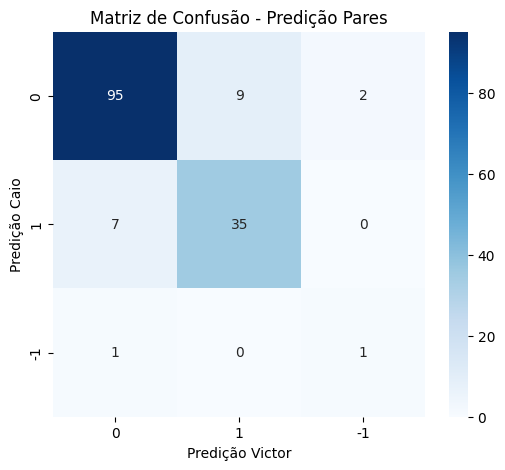

In [ ]:
labels = ["0", "1", "-1"] # classes

plt.figure(figsize=(6,5))
sns.heatmap(confusion, annot=True, fmt=".0f", cmap="Blues", xticklabels=labels, yticklabels=labels) #desenha a matriz de confusão como uma "matriz de calor"

plt.xlabel("Predição Victor")
plt.ylabel("Predição Caio")
plt.title("Matriz de Confusão - Predição Pares")
plt.show()

In [ ]:
mapa = {-1: "Indeterminado", 0: "Não Conflito", 1: "Conflito"}

for i in range(len(idx_diff)):
  print("Tweet 1: ", df_caio.loc[idx_diff[i], "tweet_1"])
  print("Tweet 2: ", df_caio.loc[idx_diff[i], "tweet_2"])
  print("Classificação Caio: ", mapa[int(df_caio.loc[idx_diff[i], "Conflict"])])
  print("Classificação Victor: ", mapa[int(df_victor.loc[idx_diff[i], "Conflict"])])
  print()

Tweet 1:  Doria disse que SP não vai seguir o protocolo do ministério da saúde para receitar cloroquina no inicio dos sintomas de covid-19. O sujeito agora além de ditador, também é um genocida.
Tweet 2:  Tem que dar papo para as provocações do Doria, ele tem outros interesses diferente da população o foco é o usuário do Sistema  se quer tomar a cloroquina ou não se o médico prescreve ou não dependendo do caso.
Classificação Caio:  Não Conflito
Classificação Victor:  Indeterminado

Tweet 1:  "Bolsonaristas criam 'corrente do bem' e se medicam com cloroquina, azitromicina e antipulgas".  Antipulgas. Antipulgas. ANTIPULGAS.
Tweet 2:  Antipulgas... pessoal precavido e consciente de si mesmo... kkkk
Classificação Caio:  Conflito
Classificação Victor:  Não Conflito

Tweet 1:  Adivinha quem tá com o rab0 cheio de cachaça já na hora do almoço?  Quem é de direita acredita na cloroquina e quem é de esquerda na jararaca cretina.
Tweet 2:  Encheu o CÚ de cachaça e falou merda!!
Classificação Caio

# **Criando Dataset das divergencias**

In [ ]:
div_cloroquina = df_caio.iloc[idx_diff].drop('Conflict', axis=1)
div_cloroquina['Conflict_caio'] = df_caio['Conflict'].iloc[idx_diff].astype(int)
div_cloroquina['Conflict_victor'] = df_victor['Conflict'].iloc[idx_diff].astype(int)
div_cloroquina['Conflict'] = np.nan

In [ ]:
div_cloroquina.shape

(19, 9)

In [ ]:
div_cloroquina_final = div_cloroquina.drop(columns=['Conflict_caio', 'Conflict_victor'])
div_cloroquina_final

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Tipo,Conflict
1,Doria disse que SP não vai seguir o protocolo ...,"Tem que dar papo para as provocações do Doria,...",1,0.428650,0.571350,Incerta,NaN
3,"""Bolsonaristas criam 'corrente do bem' e se me...",Antipulgas... pessoal precavido e consciente d...,2,0.577303,0.422697,Incerta,NaN
19,Adivinha quem tá com o rab0 cheio de cachaça j...,Encheu o CÚ de cachaça e falou merda!!,2,0.543904,0.456096,Incerta,NaN
34,...,gente sério toma no cu né? ele é uma criança e...,2,0.450936,0.549064,Incerta,NaN
35,"Esquerda grita: ""Cloroquina NÃO; tem que levar...",Enquanto o presidente receita medicamento em e...,0,0.589297,0.410703,Incerta,NaN
41,Adivinha quem tá com o rab0 cheio de cachaça j...,"""quem é da direita acredita na cloroquina"", ata",1,0.589858,0.410142,Incerta,NaN
55,Bolsonaro quer aplicar Cloroquina a qualquer c...,Muita gente precisa ler o termo de responsabil...,1,0.122558,0.877442,Alta,NaN
59,Vi no Jornal da Globo uma descrição dos efeito...,Eu sei por que eles foram curados pelo protoco...,2,0.193353,0.806647,Alta,NaN
69,"- Ainda não existe comprovação científica, mas...",Algum médico ou instituição médica assinou isso?,2,0.183290,0.816710,Alta,NaN
70,"- Ainda não existe comprovação científica, mas...",pq ele escreve como se tivesse num dialogo,2,0.193726,0.806274,Alta,NaN


In [ ]:
div_cloroquina_final.to_csv("divergencias_cloroquina_exploratoria.csv", index=False, encoding="utf-8")
files.download("divergencias_cloroquina_exploratoria.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Criando Dataset das Convergencias**




In [ ]:
conv_cloroquina = df_caio.drop(index=idx_diff, errors='ignore')

In [ ]:
conv_cloroquina.shape

(131, 7)

In [ ]:
conv_cloroquina

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict,Tipo
0,- Apesar de Cientistas Esquerdistas Comunistas...,Senador em um ato terrorista e ditatorial ─ a...,0,0.493858,0.506142,0.0,Incerta
2,Doria disse que SP não vai seguir o protocolo ...,O negócio dele é filmar suas coletivas para us...,2,0.416982,0.583018,0.0,Incerta
4,Qual é a cloroquina da sua profissão?,As pessoas perguntando vc sabe chorar? Quando ...,2,0.539129,0.460871,0.0,Incerta
5,Qual é a cloroquina da sua profissão?,"A propria, junto com “tem dipirona generico se...",2,0.588782,0.411218,0.0,Incerta
6,O MS muda o protocolo e recomenda o uso da clo...,Esse governo é realmente de matar!,2,0.457356,0.542644,0.0,Incerta
...,...,...,...,...,...,...,...
145,"Bolsonaro: ""Direita toma cloroquina e esquerda...",O erro de vocês é acreditar em Salvador da pát...,2,0.565172,0.434828,0.0,Incerta
146,"Sobre a piada Cloroquina e tubaína, Dra Gisele...",Na verdade haja pano pra essa Dra. Gisele Soares,2,0.594047,0.405953,0.0,Incerta
147,Simples assim: a direita toma Cloroquina e a e...,AGORA VAMOS ver se o povo descobre quem quer v...,2,0.552243,0.447757,0.0,Incerta
148,"Ouvi dizer -- mas, juro, não acredito -- que o...",pois eu acredito se fosse supositório podia se...,2,0.477929,0.522071,0.0,Incerta


In [ ]:
#adicionando as classificações do professor
#file_class_aborto_prof = "1FSUrpSaiBAp5Gho-CsEw6kse3q4wCB8B"
#url = f"https://drive.google.com/uc?id={file_class_aborto_prof}"
#gdown.download(url, "aborto_class_prof.csv", quiet=False)
#df_class_prof = pd.read_csv ("aborto_class_prof.csv")

In [ ]:
#df_class_prof

In [ ]:
#df_desempate = div_aborto.merge(df_class_prof, on=['tweet_1', 'tweet_2'], how='inner')
#df_desempate = df_desempate.drop(columns=['Conflict_x', 'Class_y'])
#df_desempate = df_desempate.rename(columns={'Class_x': 'Class', 'Conflict_y': 'Conflict_prof'})
#df_desempate

In [ ]:
def resolver_conflito(row):
    prof = row['Conflict_prof']
    caio = row['Conflict_caio']
    victor = row['Conflict_victor']

    if prof == caio or prof == victor:
        return prof
    else:
        return -1

#df_desempate['Conflict'] = df_desempate.apply(resolver_conflito, axis=1)

In [ ]:
#df_desempate

In [ ]:
#df_desempate = df_desempate.drop(columns=['Conflict_caio', 'Conflict_victor', 'Conflict_prof'])
#df_desempate

In [ ]:
#conv_aborto = pd.concat([conv_aborto, df_desempate], ignore_index=True, axis = 0)
#conv_aborto

In [ ]:
conv_cloroquina.to_csv("convergencias_cloroquina_exploratoria.csv", index=False, encoding="utf-8")
files.download("convergencias_cloroquina_exploratoria.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Dataset com pares não anotados**

In [ ]:
remainig_df = df_remaining.drop('Conflict', axis=1)
remainig_df

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Tipo
150,"nossa mano, como assim? seu caso não tá estáve...","o meu caso já passou, esse ai é o protocolo qu...",1,0.101858,0.898141,Alta
151,"- Ainda não existe comprovação científica, mas...",eu pensei que era zoeira essa frase nao sei p...,2,0.119899,0.880101,Alta
152,A campanha contra a cloroquina (na qual o Anta...,"Tamiflu também não tinha na época (2009), foi ...",1,0.146861,0.853139,Alta
153,A Justiça nega a divulgação do receituário do ...,Ué. Mas pq não divulgar Dr uip.... Ops Paulo ...,2,0.199137,0.800863,Alta
154,"- Ainda não existe comprovação científica, mas...","AIAI, AQUELES ""MAS""...",2,0.105675,0.894325,Alta
...,...,...,...,...,...,...
2095,Militar nomeado no SUS publicou fake news sobr...,Não salva um!,2,0.977590,0.022410,Random
2096,"Gente, isso não pode ser sério Isso é demênci...",Isso pra mim não difere da crença nos objetos ...,2,0.925530,0.074470,Random
2097,1) O efeito colateral da Cloroquina MAL RECEIT...,Bom dia meu nobre deputado!A hidrocloquina é u...,2,0.760811,0.239189,Random
2098,ISTO É MUITO GRAVE Mandetta%20diz%20que%20Bol...,"Mandetta: ""Nesse tempo em que o pessoal de dir...",0,0.988244,0.011756,Random


In [ ]:
remainig_df.to_csv("cloroquina_nao_anotado_exploratoria.csv", index=False, encoding="utf-8")
files.download("cloroquina_nao_anotado_exploratoria.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>